In [1]:
# 라이브러리 불러오기
import pandas as pd

# read_csv() 함수로 CSV 파일을 가져와서 df로 변환
df = pd.read_csv('./data/stock-data.csv')

# 데이터 내용 및 자료형 자료형 확인
print(df.head())
print('\n')
print(df.info())

         Date  Close  Start   High    Low  Volume
0  2018-07-02  10100  10850  10900  10000  137977
1  2018-06-29  10700  10550  10900   9990  170253
2  2018-06-28  10400  10900  10950  10150  155769
3  2018-06-27  10900  10800  11050  10500  133548
4  2018-06-26  10800  10900  11000  10700   63039


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    20 non-null     str  
 1   Close   20 non-null     int64
 2   Start   20 non-null     int64
 3   High    20 non-null     int64
 4   Low     20 non-null     int64
 5   Volume  20 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.1 KB
None


In [2]:
# 문자열 데이터(시리즈 객체)를 판다스 Timestamp로 변환
df['new_Date'] = pd.to_datetime(df['Date'])   #df에 새로운 열로 추가

# 데이터 내용 및 자료형 자료형 확인
print(df.head())
print('\n')
print(df.info())
print('\n')
print(type(df['new_Date'][0]))

         Date  Close  Start   High    Low  Volume   new_Date
0  2018-07-02  10100  10850  10900  10000  137977 2018-07-02
1  2018-06-29  10700  10550  10900   9990  170253 2018-06-29
2  2018-06-28  10400  10900  10950  10150  155769 2018-06-28
3  2018-06-27  10900  10800  11050  10500  133548 2018-06-27
4  2018-06-26  10800  10900  11000  10700   63039 2018-06-26


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20 non-null     str           
 1   Close     20 non-null     int64         
 2   Start     20 non-null     int64         
 3   High      20 non-null     int64         
 4   Low       20 non-null     int64         
 5   Volume    20 non-null     int64         
 6   new_Date  20 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 1.2 KB
None


<class 'pandas.Timestamp'>


In [3]:
# 시계열 값으로 변환된 열을 새로운 행 인덱스로 지정. 기존 날짜 열은 삭제
df = df.set_index('new_Date')
df = df.drop('Date', axis=1)

# 데이터 내용 및 자료형 자료형 확인
print(df.head())
print('\n')
print(df.info())

            Close  Start   High    Low  Volume
new_Date                                      
2018-07-02  10100  10850  10900  10000  137977
2018-06-29  10700  10550  10900   9990  170253
2018-06-28  10400  10900  10950  10150  155769
2018-06-27  10900  10800  11050  10500  133548
2018-06-26  10800  10900  11000  10700   63039


<class 'pandas.DataFrame'>
DatetimeIndex: 20 entries, 2018-07-02 to 2018-06-01
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Close   20 non-null     int64
 1   Start   20 non-null     int64
 2   High    20 non-null     int64
 3   Low     20 non-null     int64
 4   Volume  20 non-null     int64
dtypes: int64(5)
memory usage: 960.0 bytes
None


In [4]:
# DatetimeIndex
pd.DatetimeIndex(["2022-12-25", "2023/01/25"])

DatetimeIndex(['2022-12-25', '2023-01-25'], dtype='datetime64[us]', freq=None)

In [5]:
# Timestamp
pd.Timestamp("2023-12-25")

Timestamp('2023-12-25 00:00:00')

In [6]:
# 문자열 포맷
pd.to_datetime("2023년 12월 25일", format="%Y년 %m월 %d일")

Timestamp('2023-12-25 00:00:00')

In [8]:
# 문자열 포맷
pd.to_datetime("12-12-2023 23:59:59", format="%d-%m-%Y %H:%M:%S")

Timestamp('2023-12-12 23:59:59')

In [9]:
# 라이브러리 불러오기
import pandas as pd

# 날짜 형식의 문자열로 구성되는 리스트 정의
dates = ['2019-01-01', '2020-03-01', '2021-06-01']

# 문자열 데이터(시리즈 객체)를 판다스 Timestamp로 변환
ts_dates = pd.to_datetime(dates)   
print(ts_dates)

# Timestamp를 Period로 변환
pr_day = ts_dates.to_period(freq='D')
print(pr_day)
pr_month = ts_dates.to_period(freq='M')
print(pr_month)
pr_year = ts_dates.to_period(freq='Y')
print(pr_year)

DatetimeIndex(['2019-01-01', '2020-03-01', '2021-06-01'], dtype='datetime64[us]', freq=None)
PeriodIndex(['2019-01-01', '2020-03-01', '2021-06-01'], dtype='period[D]')
PeriodIndex(['2019-01', '2020-03', '2021-06'], dtype='period[M]')
PeriodIndex(['2019', '2020', '2021'], dtype='period[Y-DEC]')


In [10]:
# 라이브러리 불러오기
import pandas as pd

# Timestamp의 배열 만들기 - 월 간격, 월의 시작일 기준
ts_ms = pd.date_range(start='2024-01-01',    # 날짜 범위의 시작
                   end=None,                 # 날짜 범위의 끝
                   periods=6,                # 생성할 Timestamp의 개수
                   freq='MS',                # 시간 간격 (MS: 월의 시작일)
                   tz='Asia/Seoul')          # 시간대(timezone)

print(ts_ms)

DatetimeIndex(['2024-01-01 00:00:00+09:00', '2024-02-01 00:00:00+09:00',
               '2024-03-01 00:00:00+09:00', '2024-04-01 00:00:00+09:00',
               '2024-05-01 00:00:00+09:00', '2024-06-01 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='MS')


In [11]:
# 월 간격, 월의 마지막 날 기준
ts_me = pd.date_range('2024-01-01', periods=6, 
                       freq='ME',              # 시간 간격 (ME: 월의 마지막 날)
                       tz='Asia/Seoul')        # 시간대(timezone)
print(ts_me)

DatetimeIndex(['2024-01-31 00:00:00+09:00', '2024-02-29 00:00:00+09:00',
               '2024-03-31 00:00:00+09:00', '2024-04-30 00:00:00+09:00',
               '2024-05-31 00:00:00+09:00', '2024-06-30 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='ME')


In [12]:
# 분기(3개월) 간격, 월의 첫째 날 기준
ts_3m = pd.date_range('2024-01-01', periods=6, 
                       freq='3MS',             # 시간 간격 (3MS: 3개월)
                       tz='Asia/Seoul')        # 시간대(timezone)
print(ts_3m)

DatetimeIndex(['2024-01-01 00:00:00+09:00', '2024-04-01 00:00:00+09:00',
               '2024-07-01 00:00:00+09:00', '2024-10-01 00:00:00+09:00',
               '2025-01-01 00:00:00+09:00', '2025-04-01 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='3MS')


In [13]:
# 라이브러리 불러오기
import pandas as pd

# Period 배열 만들기 - 1개월 주기
pr_m = pd.period_range(start='2024-01-01',     # 날짜 범위의 시작
                   end=None,                   # 날짜 범위의 끝
                   periods=3,                  # 생성할 Period 개수
                   freq='M')                   # 주기 (M: 월)
print(pr_m)

PeriodIndex(['2024-01', '2024-02', '2024-03'], dtype='period[M]')


In [14]:
# Period 배열 만들기 - 1시간 주기
pr_h = pd.period_range(start='2024-01-01',     # 날짜 범위의 시작
                   end=None,                   # 날짜 범위의 끝
                   periods=3,                  # 생성할 Period 개수
                   freq='h')                   # 주기 (h: 시간)
print(pr_h)

PeriodIndex(['2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 02:00'], dtype='period[h]')


In [15]:
# Period 배열 만들기 - 2일 주기
pr_2h = pd.period_range(start='2024-01-01',    # 날짜 범위의 시작
                   end=None,                   # 날짜 범위의 끝
                   periods=3,                  # 생성할 Period 개수
                   freq='2d')                  # 주기 (2d: 2일)
print(pr_2h)

PeriodIndex(['2024-01-01', '2024-01-03', '2024-01-05'], dtype='period[2D]')


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_24892\1035229658.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  pr_2h = pd.period_range(start='2024-01-01',    # 날짜 범위의 시작


In [16]:
# 라이브러리 불러오기
import pandas as pd

# read_csv() 함수로 파일 읽어와서 df로 변환
df = pd.read_csv('./data/stock-data.csv')

# 문자열인 날짜 데이터를 판다스 Timestamp로 변환
df['new_Date'] = pd.to_datetime(df['Date'])   #df에 새로운 열로 추가
df.head()

,Date,Close,Start,High,Low,Volume,new_Date
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26


In [17]:
# dt 속성을 이용하여 new_Date 열의 년월일 정보를 년, 월, 일로 구분
df['Year'] = df['new_Date'].dt.year
df['Month'] = df['new_Date'].dt.month
df['Day'] = df['new_Date'].dt.day
df.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Month,Day
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26


In [18]:
# Timestamp를 Period로 변환하여 년월일 표기 변경하기
df['Date_yr'] = df['new_Date'].dt.to_period(freq='Y')
df['Date_m'] = df['new_Date'].dt.to_period(freq='M')
df.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Month,Day,Date_yr,Date_m
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2,2018,2018-07
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06


In [19]:
# 2018년 6월 데이터만 추출 (문자열 속성 활용)
df_june = df[df['Date_m'].astype(str).str.fullmatch('2018-06')]
df_june.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Month,Day,Date_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06


In [20]:
# 2018년 6월 데이터만 추출 (Period 객체 활용)
df_june2 = df[df['Date_m'] == pd.Period('2018-06')]
df_june2.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Month,Day,Date_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06


In [21]:
# 원하는 열을 새로운 행 인덱스로 지정
df_june = df_june.set_index('new_Date')
df_june.head()

,Date,Close,Start,High,Low,Volume,Year,Month,Day,Date_yr,Date_m
new_Date,,,,,,,,,,,
2018-06-29,2018-06-29,10700,10550,10900,9990,170253,2018,6,29,2018,2018-06
2018-06-28,2018-06-28,10400,10900,10950,10150,155769,2018,6,28,2018,2018-06
2018-06-27,2018-06-27,10900,10800,11050,10500,133548,2018,6,27,2018,2018-06
2018-06-26,2018-06-26,10800,10900,11000,10700,63039,2018,6,26,2018,2018-06
2018-06-25,2018-06-25,11150,11400,11450,11000,55519,2018,6,25,2018,2018-06


In [22]:
# 라이브러리 불러오기
import pandas as pd

# read_csv() 함수로 파일 읽어와서 df로 변환
df = pd.read_csv('./data/stock-data.csv')

# 문자열인 날짜 데이터를 판다스 Timestamp로 변환
df['new_Date'] = pd.to_datetime(df['Date'])   #df에 새로운 열로 추가

# 원하는 열을 새로운 행 인덱스로 지정하고 오름차순 정렬
df = df.set_index('new_Date').sort_index()

print(df.head())
print('\n')
print(df.index)

                  Date  Close  Start   High    Low  Volume
new_Date                                                  
2018-06-01  2018-06-01  11900  11800  12100  11750   32062
2018-06-04  2018-06-04  11900  11900  12200  11700   25171
2018-06-05  2018-06-05  12150  11800  12250  11800   42485
2018-06-07  2018-06-07  11950  12200  12300  11900   49088
2018-06-08  2018-06-08  11950  11950  12200  11800   59258


DatetimeIndex(['2018-06-01', '2018-06-04', '2018-06-05', '2018-06-07',
               '2018-06-08', '2018-06-11', '2018-06-12', '2018-06-14',
               '2018-06-15', '2018-06-18', '2018-06-19', '2018-06-20',
               '2018-06-21', '2018-06-22', '2018-06-25', '2018-06-26',
               '2018-06-27', '2018-06-28', '2018-06-29', '2018-07-02'],
              dtype='datetime64[us]', name='new_Date', freq=None)


In [25]:
# 부분 문자열 인덱싱 1
df.loc['2018-06-27']

Date      2018-06-27
Close          10900
Start          10800
High           11050
Low            10500
Volume        133548
Name: 2018-06-27 00:00:00, dtype: object

In [26]:
# 부분 문자열 인덱싱 2
df.loc['2018-07']

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [27]:
# 부분 문자열 인덱싱 3
df.loc['2018-06-27':'2018-07-02']

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-27,2018-06-27,10900,10800,11050,10500,133548
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [28]:
# 부분 문자열 인덱싱 4
df[df.index < '2018-06-05']

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-01,2018-06-01,11900,11800,12100,11750,32062
2018-06-04,2018-06-04,11900,11900,12200,11700,25171


In [29]:
# 시간 자료형을 활용한 인덱싱 1
df.loc[pd.Timestamp(2018, 6, 27):pd.Timestamp(2018, 7, 2)]  

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-27,2018-06-27,10900,10800,11050,10500,133548
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [30]:
# 시간 자료형을 활용한 인덱싱 2
df.loc[pd.Timestamp(2018, 6, 27, 10, 30, 0):pd.Timestamp(2018, 7, 2, 23, 59, 59)]  

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-07-02,2018-07-02,10100,10850,10900,10000,137977


In [31]:
# 날짜, 시간의 절대적 차이 1
print(pd.Timedelta("1 days"))
print(pd.Timedelta(days=1))
print(pd.Timedelta("1 days 1 hours 1 minutes, 1 seconds"))
print(pd.Timedelta(days=1, hours=1, minutes=1, seconds=1))

1 days 00:00:00
1 days 00:00:00
1 days 01:01:01
1 days 01:01:01


In [32]:
# 날짜, 시간의 절대적 차이 2
pd.to_timedelta(["1 days", "3 hours"])

TimedeltaIndex(['1 days 00:00:00', '0 days 03:00:00'], dtype='timedelta64[us]', freq=None)

In [33]:
# 날짜, 시간의 절대적 차이 3
a = df.index
print(a)

b = pd.Timestamp('2018-07-03') - a
print(b)

c = a + pd.Timedelta(days=1)
print(c)

print(c.min())
print(c.max())

DatetimeIndex(['2018-06-01', '2018-06-04', '2018-06-05', '2018-06-07',
               '2018-06-08', '2018-06-11', '2018-06-12', '2018-06-14',
               '2018-06-15', '2018-06-18', '2018-06-19', '2018-06-20',
               '2018-06-21', '2018-06-22', '2018-06-25', '2018-06-26',
               '2018-06-27', '2018-06-28', '2018-06-29', '2018-07-02'],
              dtype='datetime64[us]', name='new_Date', freq=None)
TimedeltaIndex(['32 days', '29 days', '28 days', '26 days', '25 days',
                '22 days', '21 days', '19 days', '18 days', '15 days',
                '14 days', '13 days', '12 days', '11 days',  '8 days',
                 '7 days',  '6 days',  '5 days',  '4 days',  '1 days'],
               dtype='timedelta64[us]', name='new_Date', freq=None)
DatetimeIndex(['2018-06-02', '2018-06-05', '2018-06-06', '2018-06-08',
               '2018-06-09', '2018-06-12', '2018-06-13', '2018-06-15',
               '2018-06-16', '2018-06-19', '2018-06-20', '2018-06-21',
            

In [34]:
# 라이브러리 불러오기
import pandas as pd

# read_csv() 함수로 파일 읽어와서 df로 변환
df = pd.read_csv('./data/stock-data.csv')

# 문자열인 날짜 데이터를 판다스 Timestamp로 변환
df['new_Date'] = pd.to_datetime(df['Date'])  
df = df.drop(columns=['Date'])

# 원하는 열을 새로운 행 인덱스로 지정하고 오름차순 정렬
df = df.set_index('new_Date').sort_index()

ts = df.head(10)
ts

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258
2018-06-11,11950,12000,12250,11950,62293
2018-06-12,13200,12200,13300,12050,558148
2018-06-14,13450,13200,13700,13150,347451
2018-06-15,13400,13600,13600,12900,201376


In [35]:
# 배열의 데이터를 이동 (날짜 데이터는 그대로 유지)
ts.shift(1)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,NaN,NaN,NaN,NaN,NaN
2018-06-04,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-05,11900.0,11900.0,12200.0,11700.0,25171.0
2018-06-07,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-08,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-11,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-12,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-14,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-15,13450.0,13200.0,13700.0,13150.0,347451.0


In [36]:
ts.shift(-2)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-04,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-05,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-07,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-08,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-11,13450.0,13200.0,13700.0,13150.0,347451.0
2018-06-12,13400.0,13600.0,13600.0,12900.0,201376.0
2018-06-14,12000.0,13400.0,13400.0,12000.0,309787.0
2018-06-15,NaN,NaN,NaN,NaN,NaN


In [37]:
# 날짜 데이터를 전부 이동
ts.shift(3, freq="D")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-04,11900,11800,12100,11750,32062
2018-06-07,11900,11900,12200,11700,25171
2018-06-08,12150,11800,12250,11800,42485
2018-06-10,11950,12200,12300,11900,49088
2018-06-11,11950,11950,12200,11800,59258
2018-06-14,11950,12000,12250,11950,62293
2018-06-15,13200,12200,13300,12050,558148
2018-06-17,13450,13200,13700,13150,347451
2018-06-18,13400,13600,13600,12900,201376


In [38]:
# Frequency 전환
ts.asfreq('5D')

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-06,NaN,NaN,NaN,NaN,NaN
2018-06-11,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-16,NaN,NaN,NaN,NaN,NaN


In [40]:
ts.asfreq('5D', method='bfill')

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-06,11950,12200,12300,11900,49088
2018-06-11,11950,12000,12250,11950,62293
2018-06-16,12000,13400,13400,12000,309787


In [41]:
# Resampling
print(ts.resample("3B"))

ts.resample("3B").sum()

DatetimeIndexResampler [freq=<3 * BusinessDays>, closed=left, label=left, convention=start, origin=start_day]


,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,35950,35500,36550,35250,99718
2018-06-06,23900,24150,24500,23700,108346
2018-06-11,25150,24200,25550,24000,620441
2018-06-14,38850,40200,40700,38050,858614


In [42]:
# Window Operation (데이터 개수를 기준)
ts.rolling(window=3).sum()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,NaN,NaN,NaN,NaN,NaN
2018-06-04,NaN,NaN,NaN,NaN,NaN
2018-06-05,35950.0,35500.0,36550.0,35250.0,99718.0
2018-06-07,36000.0,35900.0,36750.0,35400.0,116744.0
2018-06-08,36050.0,35950.0,36750.0,35500.0,150831.0
2018-06-11,35850.0,36150.0,36750.0,35650.0,170639.0
2018-06-12,37100.0,36150.0,37750.0,35800.0,679699.0
2018-06-14,38600.0,37400.0,39250.0,37150.0,967892.0
2018-06-15,40050.0,39000.0,40600.0,38100.0,1106975.0


In [43]:
# Window Operation (날짜 수를 기준)
ts.rolling(window='3D').sum()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-04,11900.0,11900.0,12200.0,11700.0,25171.0
2018-06-05,24050.0,23700.0,24450.0,23500.0,67656.0
2018-06-07,24100.0,24000.0,24550.0,23700.0,91573.0
2018-06-08,23900.0,24150.0,24500.0,23700.0,108346.0
2018-06-11,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-12,25150.0,24200.0,25550.0,24000.0,620441.0
2018-06-14,26650.0,25400.0,27000.0,25200.0,905599.0
2018-06-15,26850.0,26800.0,27300.0,26050.0,548827.0


In [44]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# read_csv() 함수로 파일 읽어와서 df로 변환
df = pd.read_csv('./data/stock-data.csv')

# 문자열인 날짜 데이터를 판다스 Timestamp로 변환
df['new_Date'] = pd.to_datetime(df['Date'])  
df = df.drop(columns=['Date'])

# 원하는 열을 새로운 행 인덱스로 지정하고 오름차순 정렬
df = df.set_index('new_Date').sort_index()

df.head()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258


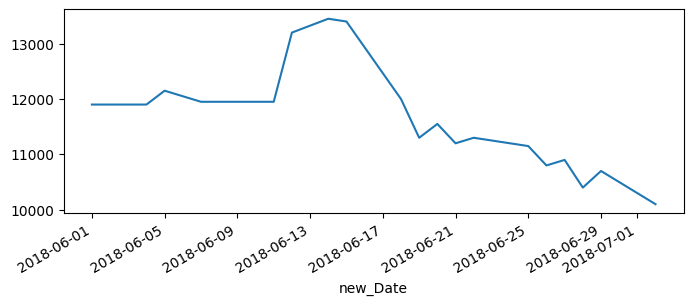

In [47]:
# 종가(Close) 변화를 시각화 (시리즈 객체)
df['Close'].plot(figsize=(8, 3));

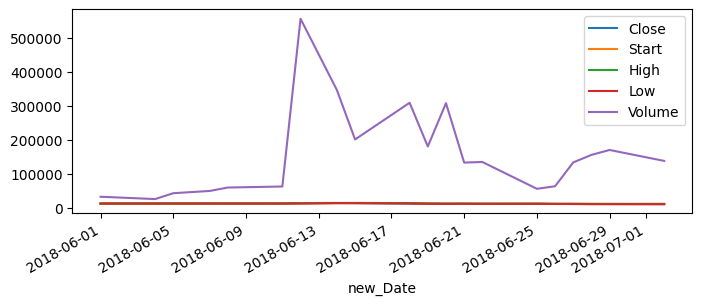

In [48]:
# 데이터프레임 전체 시각화
df.plot(figsize=(8, 3));

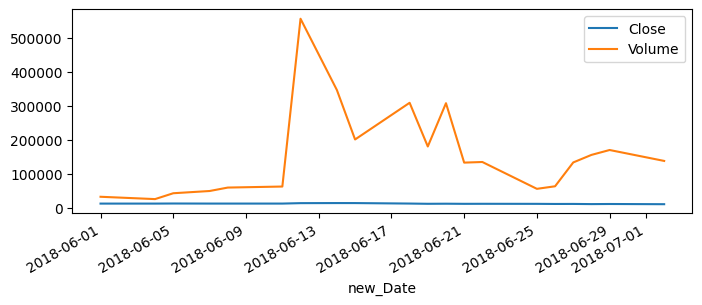

In [49]:
# 종가(Close)와 거래량(volume) 변화를 함께 시각화 
df[['Close', 'Volume']].plot(figsize=(8, 3));

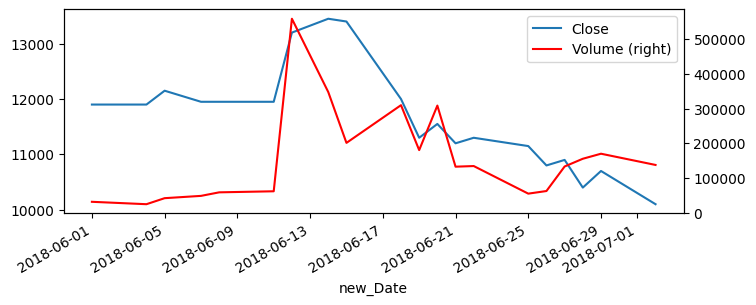

In [50]:
# 보조축 표시
df["Close"].plot(label='Close', legend=True, figsize=(8, 3));
df["Volume"].plot(secondary_y=True, style="r", label='Volume', legend=True);

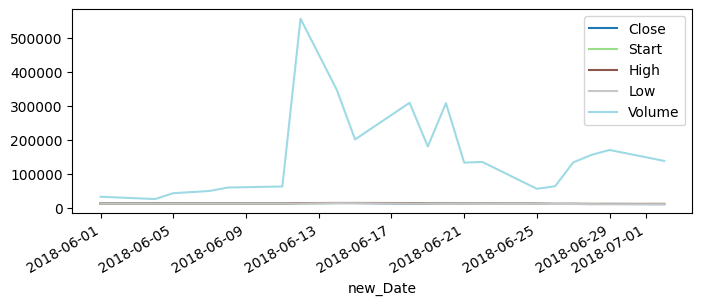

In [51]:
# 색상 맵 
df.plot(figsize=(8, 3), colormap="tab20");

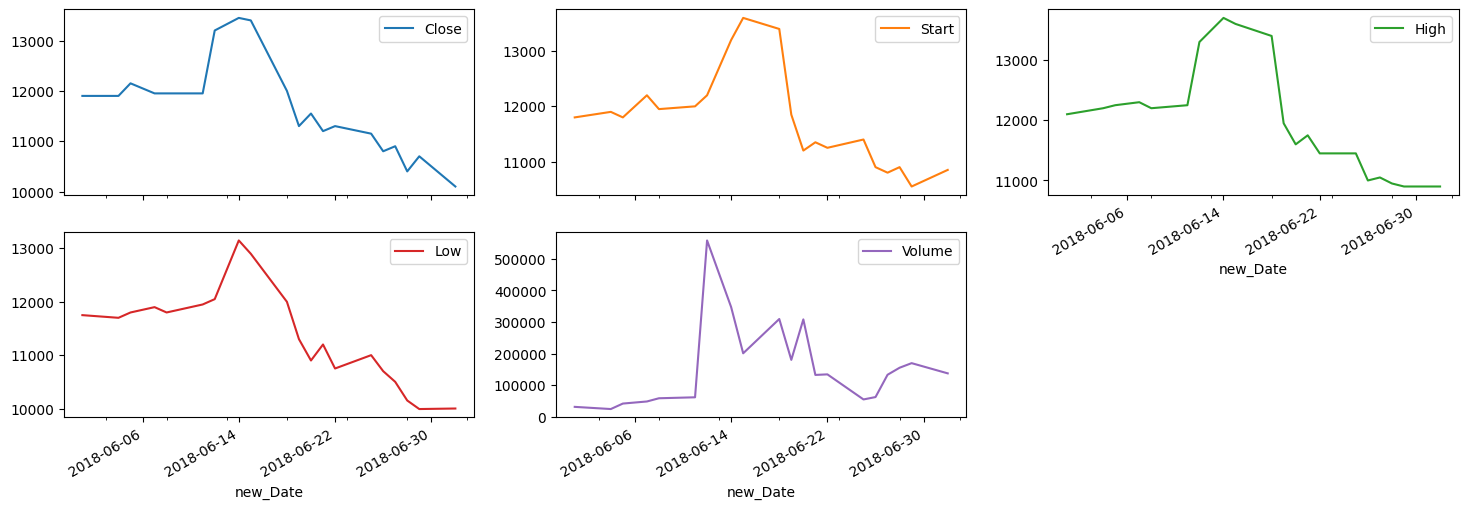

In [52]:
# 그리드 레이아웃 - 서브 플롯 
axes = df.plot(subplots=True, layout=(2, 3), figsize=(18, 6), sharex=True, sharey=False)

# x 축의 주요 레이블 위치를 최대 5개로 제한
axes[0, 0].xaxis.set_major_locator(plt.MaxNLocator(5))

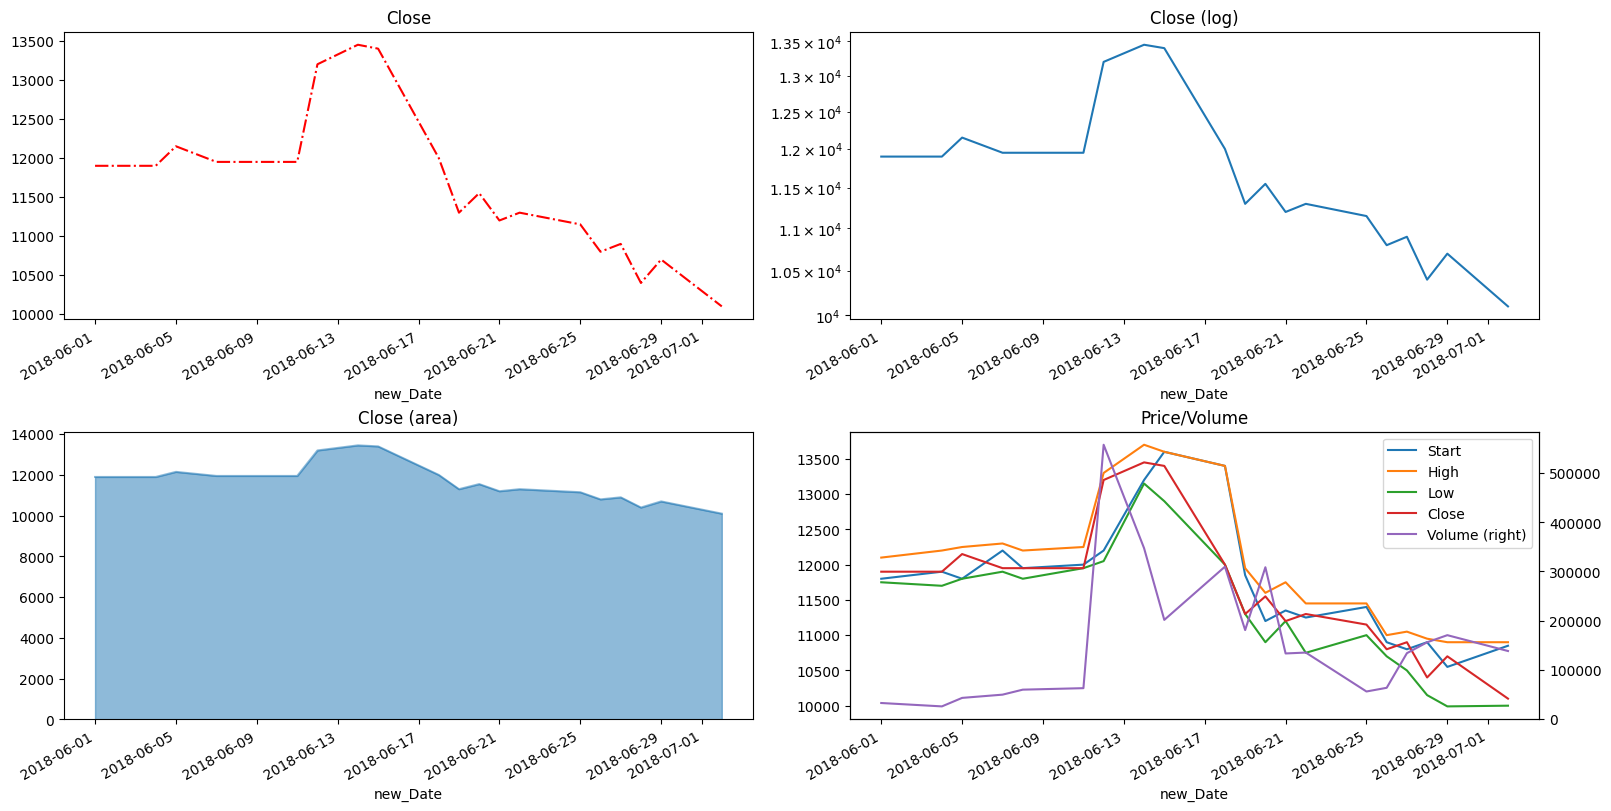

In [53]:
# Figure, Axes 객체
fig, axes = plt.subplots(nrows=2, ncols=2, 
                         figsize=(16, 8),
                         constrained_layout=True)

# 선 스타일
df['Close'].plot(ax=axes[0, 0], style="r-.")
axes[0, 0].set_title('Close')

# 로그 스케일 변환
df['Close'].plot(ax=axes[0, 1], logy=True)
axes[0, 1].set_title('Close (log)')

# 면적 그래프
df['Close'].plot(ax=axes[1, 0], kind='area', alpha=0.5)
axes[1, 0].set_title('Close (area)')

# 보조축 적용
df[['Start', 'High', 'Low', 'Close']].plot(ax=axes[1, 1], legend=True)
df['Volume'].plot(ax=axes[1, 1], legend=True, secondary_y=True)
axes[1, 1].set_title('Price/Volume')

plt.show()

In [1]:
# 라이브러리 불러오기
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# 예제 2.7의 get_financials() 함수를 사용 (Dapada apiKey 필요)

my_key = ''

# 특정 종목(stockCode)의 재무항목(indicatorName) 데이터를 가져오는 함수를 정의
def get_financials(stockCode, indicatorName, apiKey, consolidated=True, ttm=True):
    
    if consolidated:   # 연결 기준
        if ttm:        # Trailing 12 Months (12개월 누적)
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByTTM?apiKey={apiKey}&indicatorName={indicatorName}&stockCode={stockCode}"            
        else:          # 해당 분기 기준 (3개월 집계)
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByCUR?apiKey={apiKey}&indicatorName={indicatorName}&stockCode={stockCode}"       
            
    else:              # 별도 기준
        if ttm:        # Trailing 12 Months (12개월 누적)
            url = f"https://api.dapada.io/company/getSeparatedFinancialDataByTTM?apiKey={apiKey}&indicatorName={indicatorName}&stockCode={stockCode}"            
        else:          # 해당 분기 기준 (3개월 집계)
            url = f"https://api.dapada.io/company/getSeparatedFinancialDataByCUR?apiKey={apiKey}&indicatorName={indicatorName}&stockCode={stockCode}"       
           
    headers = {"apiKey": f"{apiKey}"}
    response = requests.get(url, headers=headers)
    result = response.json()
    return pd.DataFrame(result)

# 삼성전자(005930)의 연결 재무제표 (분기 기준)에서 '영업이익' 항목의 데이터 수집
df_samsung = get_financials(stockCode='005930', 
                            indicatorName='영업이익', 
                            apiKey=my_key, 
                            consolidated=True, 
                            ttm=False)

# 영업이익의 변화율을 계산
df_samsung['change'] = df_samsung['value'].pct_change()

# quarter 열을 인덱스로 설정
df_samsung = df_samsung.set_index('quarter')

# SK하이닉스(000660)의 연결 재무제표 (분기 기준)에서 '영업이익' 항목의 데이터 수집
df_skhynix = get_financials(stockCode='000660', 
                            indicatorName='영업이익', 
                            apiKey=my_key, 
                            consolidated=True, 
                            ttm=False)

# 영업이익의 변화율을 계산
df_skhynix['change'] = df_skhynix['value'].pct_change()

# quarter 열을 인덱스로 설정
df_skhynix = df_skhynix.set_index('quarter')

df_samsung

ValueError: If using all scalar values, you must pass an index

In [55]:
# 데이터 값의 형식을 지정 (소수정 이하 둘째 자리, 천 단위, 소수점 표시)
df_samsung.style.format(precision=2, thousands=',', decimal='.')

NameError: name 'df_samsung' is not defined

In [56]:
# 데이터 값의 형식을 지정 (열 이름 대문자로 변환)
df_samsung.style.format_index(str.upper, axis=1)

NameError: name 'df_samsung' is not defined

In [57]:
# 데이터 값의 형식을 지정 (행 인덱스를 소문자로 변환)
df_samsung.style.format_index(str.lower, axis=0)

NameError: name 'df_samsung' is not defined

In [58]:
# 데이터 값의 형식을 지정 (열 이름을 재지정)
df_samsung.style.relabel_index(['영업이익', '영업이익증가율'], axis=1)

NameError: name 'df_samsung' is not defined

In [59]:
# 데이터 값의 형식을 지정 (행 인덱스를 재지정)
new_dates = ['2023.09', '2023.06', '2023.03', '2022.12', '2022.09', '2022.06']
df_samsung.style.relabel_index(new_dates, axis=0)

NameError: name 'df_samsung' is not defined

In [60]:
# 연결하기 (concat)
data_styler = df_samsung.style.format(precision=2, thousands=',', decimal='.')
stat_styler = df_samsung.describe().style.format(precision=2, thousands=',', decimal='.')

data_styler.concat(stat_styler)

NameError: name 'df_samsung' is not defined

In [61]:
# Styler 객체를 통해 원본 DataFrame 얻기
df_stat_original = stat_styler.data
df_stat_original

NameError: name 'stat_styler' is not defined

In [62]:
# 데이터 숨기기 (열 제외)
df_samsung.style.hide(['value'], axis=1)

NameError: name 'df_samsung' is not defined

In [63]:
# 데이터 숨기기 (행 제외)
df_samsung.style.hide(['2023-Q3', '2022-Q3'], axis=0)

NameError: name 'df_samsung' is not defined

In [64]:
# 조건부 포맷팅 (각 열의 최대값)
df_samsung.style.highlight_max(color='lightgreen')

NameError: name 'df_samsung' is not defined

In [65]:
# 조건부 포맷팅 (각 열의 최소값)
df_samsung.style.highlight_min(color='orange')

NameError: name 'df_samsung' is not defined

In [66]:
# 조건부 포맷팅 (각 행의 최솟값)
df_samsung.style.highlight_min(color='lightblue', axis=1)

NameError: name 'df_samsung' is not defined

In [67]:
# 조건부 포맷팅 (누락 데이터)
df_samsung.style.highlight_null(color='red')

NameError: name 'df_samsung' is not defined

In [69]:
# 막대 그래프
df_samsung.style.bar(subset=['change'], color='#d65f5f')

NameError: name 'df_samsung' is not defined

In [70]:
# 삼성전자, SK하이닉스 영업이익증가율 데이터를 정리
df_opm = pd.concat([df_samsung['change'], df_skhynix['change']], axis=1)
df_opm.columns=['samsung', 'skhynix']
df_opm

NameError: name 'df_samsung' is not defined

In [71]:
# 모든 원소에 대해서 각각 스타일 적용 
def show_negative(value, props=''):
    return props if value < 0 else None

style_opm = df_opm.style.map(show_negative, props='color:red;')
style_opm

NameError: name 'df_opm' is not defined

In [72]:
def highlight_min(style, props=''):
    return np.where(style == np.nanmin(style.values), props, '')

# 데이터프레임 전체 중에서 최소값
style_opm_df = df_opm.style.apply(highlight_min, 
                                   props='color:white;background-color:darkred', 
                                   axis=None)
style_opm_df

NameError: name 'df_opm' is not defined

In [73]:
# 데이터프레임 각 열의 최소값
style_opm_col = df_opm.style.apply(highlight_min, 
                                   props='color:white;background-color:darkred', 
                                   axis=0)
style_opm_col

NameError: name 'df_opm' is not defined

In [74]:
# 데이터프레임 각 행의 최소값
style_opm_row = df_opm.style.apply(highlight_min, 
                                   props='color:white;background-color:darkred', 
                                   axis=1)
style_opm_row

NameError: name 'df_opm' is not defined

In [75]:
# 조건에 따라 다르게 적용

def profit_condition(value):
    if value < 0:
        return "Loss"
    elif value> 0:
        return "Gain"
    else:
        return "No"

def apply_condition(styler):
    styler.set_caption("Gain/Loss")
    styler = styler.format(profit_condition, subset=['change'])
    styler = styler.background_gradient(subset=['change'], axis=None, 
                                        vmin=-10, vmax=10, cmap="RdYlBu_r")
    return styler

df_samsung.style.pipe(apply_condition)

NameError: name 'df_samsung' is not defined

In [76]:
# HTML CSS 스타일링
cell_hover = {  
    'selector': 'tr:hover',
    'props': [('background-color', '#ffffb3')]
}

stat_styler.set_table_styles([cell_hover])

NameError: name 'stat_styler' is not defined